In [1]:
import warnings
warnings.filterwarnings("ignore")

### Cell 1: Text Preprocessing & Cleaning

In [2]:
import pandas as pd
import re
import string

# ------------------------------
# Text cleaning functions
# ------------------------------

def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_whitespace(text):
    if pd.isna(text):
        return text
    return " ".join(text.split())

def remove_emojis(text):
    if pd.isna(text):
        return text
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_urls(text):
    if pd.isna(text):
        return text
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_html(text):
    if pd.isna(text):
        return text
    html_pattern = re.compile(r'<.*?>')
    return html_pattern.sub(r'', text)

def remove_special_characters(text):
    if pd.isna(text):
        return text
    return re.sub(r'[^A-Za-z0-9\s\u0980-\u09FF]', '', text)

def clean_text(text):
    text = remove_urls(text)
    text = remove_html(text)
    text = remove_emojis(text)
    text = remove_punctuation(text)
    text = remove_special_characters(text)
    text = remove_whitespace(text)
    return text

# ------------------------------
# Load & clean each split
# ------------------------------
csv_paths = {
    'Train': '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/train.csv',
    'Val':   '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/val.csv',
    'Test':  '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/test.csv'
}

cleaned_output_paths = {
    'Train': '/kaggle/working/train_cleaned.csv',
    'Val':   '/kaggle/working/val_cleaned.csv',
    'Test':  '/kaggle/working/test_cleaned.csv'
}

for key in csv_paths:
    df = pd.read_csv(csv_paths[key])
    df['Title'] = df['Title'].astype(str).apply(clean_text)
    df['label'] = df['label'].astype(int)
    df.to_csv(cleaned_output_paths[key], index=False)
    print(f"Cleaned {key} shape: {df.shape}")
    print(df.head(2))
    print()

Cleaned Train shape: (5002, 14)
   SL. NO.                     Image Path  \
0        1  Thumbnails/thumbnail_9062.jpg   
1        2  Thumbnails/thumbnail_8722.jpg   

                                               Title  \
0  ব্রেন স্ট্রোকের লক্ষণ গুলি কি Brain Stroke Sym...   
1  ২য় শ্রেণি গণিত নমুনা প্রশ্ন ও উত্তর ২০২৫ ১ম স...   

                                           URL   Source  label Category  \
0   https://www.youtube.com/shorts/v9I2zu5zyqc  YouTube      1      NaN   
1  https://www.youtube.com/watch?v=eLaE8u3AbZU  YouTube      0      NaN   

      Video ID YouTube Channel  Like    View Comment Count Upload Date  \
0          NaN             NaN   NaN     NaN           NaN         NaN   
1  eLaE8u3AbZU   amar i school   5.0  1477.0    1899-12-30   4/25/2025   

  Current Date  
0          NaN  
1     5/3/2025  

Cleaned Val shape: (715, 14)
   SL. NO.                      Image Path  \
0        1   Thumbnails/thumbnail_6549.jpg   
1        2  Thumbnails/thumbnail_14236.jp

In [3]:
train_df = pd.read_csv('/kaggle/working/train_cleaned.csv')
print("Train:")
train_df.head()

Train:


,SL. NO.,Image Path,Title,URL,Source,label,Category,Video ID,YouTube Channel,Like,View,Comment Count,Upload Date,Current Date
0,1,Thumbnails/thumbnail_9062.jpg,ব্রেন স্ট্রোকের লক্ষণ গুলি কি Brain Stroke Sym...,https://www.youtube.com/shorts/v9I2zu5zyqc,YouTube,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Thumbnails/thumbnail_8722.jpg,২য় শ্রেণি গণিত নমুনা প্রশ্ন ও উত্তর ২০২৫ ১ম স...,https://www.youtube.com/watch?v=eLaE8u3AbZU,YouTube,0,NaN,eLaE8u3AbZU,amar i school,5.0,1477.0,1899-12-30,4/25/2025,5/3/2025
2,3,Thumbnails/thumbnail_13793.jpg,চ্যালেঞ্জ সামলাতে পারবে যুক্তরাষ্ট্রের সাথে সম...,https://www.youtube.com/watch?v=7dC06fs4wb4,YouTube,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Thumbnails/thumbnail_15025.jpg,কুমির চাষে আয় ১৫ কোটি টাকা না দেখলে বিশ্বাস ক...,https://www.youtube.com/watch?v=XDQppsld1dQ,YouTube,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Thumbnails/thumbnail_13884.jpg,আ লীগ নির্বাচনে থাকবে কিনা সিদ্ধান্ত কার ওপর ছ...,https://www.youtube.com/watch?v=TV9y4kWe7F8,YouTube,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
val_df = pd.read_csv('/kaggle/working/val_cleaned.csv')
print("Val:")
val_df.head()

Val:


,SL. NO.,Image Path,Title,URL,Source,label,Category,Video ID,YouTube Channel,Like,View,Comment Count,Upload Date,Current Date
0,1,Thumbnails/thumbnail_6549.jpg,হাসিনার প্লট জালিয়াতি ফাঁসছেন ২০ কর্মকর্তা DU...,https://www.youtube.com/watch?v=s_hKGdmMoJI,YouTube,0,NaN,s_hKGdmMoJI,SOMOY TV,173.0,13964.0,1/14/1900,4/18/2025,5/3/2025
1,2,Thumbnails/thumbnail_14236.jpg,কক্সবাজারে এনসিপি নেতাদের গাড়িবহরে হামলা Coxs...,https://www.youtube.com/watch?v=ijG29YTAFtM,YouTube,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Thumbnails/thumbnail_13301.jpg,WBCHSE 2025 Results LIVE উচ্চমাধ্যমিকের ফলাফল ...,https://www.youtube.com/watch?v=7OAWOzTYFzc,YouTube,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Thumbnails/thumbnail_6204.jpg,কাল থেকে পুরোদমে শুরু হচ্ছে দেশের শিক্ষা কার্য...,https://www.youtube.com/watch?v=1-2oqaRnh5M,YouTube,1,NaN,1-2oqaRnh5M,Maasranga News,1.0,134.0,1899-12-30,8/17/2024,5/3/2025
4,5,Thumbnails/thumbnail_5862.jpg,নবম শ্রেণীর পাঠ্যবই নিয়ে যে তথ্য দিলেন আসিফ ম...,https://www.youtube.com/watch?v=2pu4xEKPY_Y,YouTube,0,NaN,2pu4xEKPY_Y,SOMOY TV,18928.0,532054.0,3/3/1905,12/21/2024,5/3/2025


In [5]:
test_df = pd.read_csv('/kaggle/working/test_cleaned.csv')
print("Test:")
test_df.head()

Test:


,SL. NO.,Image Path,Title,URL,Source,label,Category,Video ID,YouTube Channel,Like,View,Comment Count,Upload Date,Current Date
0,1,Thumbnails/thumbnail_2775.jpg,অহংকারের পরিণতি কি মুফতি সাইফুল্লাহ মাহমুদআল্ল...,https://www.youtube.com/watch?v=9kVCpUrQnVQ,YouTube,0,NaN,9kVCpUrQnVQ,AKL ISLAMiC TV,2.0,83.0,1899-12-30,8/25/2022,5/3/2025
1,2,Thumbnails/thumbnail_12266.jpg,ইলেকট্রিক কেটলিতে পানি গরম করলে কত টাকা বিদ্যু...,https://www.youtube.com/watch?v=8veISEBD70k,YouTube,1,8veISEBD70k,Electricity for Life,14,716.0,2.0,12/19/2024,5/3/2025,Unavailable
2,3,Thumbnails/thumbnail_11645.jpg,বনসংরক্ষণ প্রবন্ধ রচনা মাধ্যমিক ও উচ্চমাধ্যমিক...,https://www.youtube.com/watch?v=i8Wf7KbC3g4,YouTube,0,NaN,i8Wf7KbC3g4,Scene Create,0.0,35.0,1899-12-30,2/12/2025,5/3/2025
3,4,Thumbnails/thumbnail_8109.jpg,টপ ৫ ইতিহাসের সবচেয়ে ভয়াবহ প্রাকৃতিক দুর্যোগ...,https://www.youtube.com/watch?v=sw6UVbHGMPU,YouTube,1,NaN,sw6UVbHGMPU,FactsBD,123.0,13158.0,1/2/1900,11/3/2021,5/3/2025
4,5,Thumbnails/thumbnail_3045.jpg,পাকিস্তানিরা কেন শেখ মুজিবের চেয়ে তাজউদ্দীনকে...,https://www.youtube.com/watch?v=PtOrfve9MUs,YouTube,1,NaN,PtOrfve9MUs,Enayet Chowdhury,33797.0,1319163.0,3/24/1908,12/5/2023,5/3/2025


### Cell 3: Install Dependencies

In [6]:
!pip install transformers timm

### Cell 4: Imports & Configuration

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import timm
import pandas as pd
from PIL import Image
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from timm.data import create_transform, resolve_data_config

# ================================
# Configuration Class
# ================================
class Config:
    # Cleaned CSV Paths
    TRAIN_CSV = '/kaggle/working/train_cleaned.csv'
    VAL_CSV   = '/kaggle/working/val_cleaned.csv'
    TEST_CSV  = '/kaggle/working/test_cleaned.csv'

    # Image Folders (split-wise)
    TRAIN_IMAGE_FOLDER = '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/train/Thumbnails'
    VAL_IMAGE_FOLDER   = '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/val/Thumbnails'
    TEST_IMAGE_FOLDER  = '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/test/Thumbnails'

    # Hyperparameters
    MAX_LEN       = 64
    BATCH_SIZE    = 32
    EPOCHS        = 15
    LEARNING_RATE = 2e-5
    DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Model Names

    TEXT_MODEL  = 'xlm-roberta-base'
    IMAGE_MODEL = 'swin_tiny_patch4_window7_224'

print(f"Device set to: {Config.DEVICE}")

Device set to: cuda


### Cell 5: Custom Dataset Class

In [8]:
class ClickbaitDataset(Dataset):
    def __init__(self, csv_path, image_folder, tokenizer, transform=None):
        self.df           = pd.read_csv(csv_path)
        self.image_folder = image_folder
        self.tokenizer    = tokenizer
        self.transform    = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- 1. Image Processing ---
        img_filename = os.path.basename(str(row['Image Path']).strip())
        img_path = os.path.join(self.image_folder, img_filename)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            pixel_values = self.transform(image)

        # --- 2. Text Processing ---
        text = str(row['Title'])
        encoding = self.tokenizer(
            text,
            max_length=Config.MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'pixel_values':  pixel_values,
            'input_ids':     encoding['input_ids'].flatten(),
            'attention_mask':encoding['attention_mask'].flatten(),
            'label':         torch.tensor(int(row['label']), dtype=torch.long)
        }

## Swin Transformer + XLM-RoBERTa Fusion Model

In [9]:
class SwinXLM_Fusion(nn.Module):
    def __init__(self, num_classes=2):
        super(SwinXLM_Fusion, self).__init__()

        # --- Image Encoder (Swin Transformer) ---
        # num_classes=0 removes the final classification layer to output raw features
        self.image_encoder = timm.create_model(Config.IMAGE_MODEL, pretrained=True, num_classes=0)
        
        # Get the output dimension dynamically from the timm model
        self.img_out_dim = self.image_encoder.num_features

        # --- Text Encoder (XLM-RoBERTa) ---
        self.text_encoder = AutoModel.from_pretrained(Config.TEXT_MODEL)
        self.text_out_dim = self.text_encoder.config.hidden_size # Typically 768 for base

        # --- Fusion Head ---
        # Combining both text and image feature dimensions
        fusion_dim = self.img_out_dim + self.text_out_dim
        self.fusion_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        # 1. Extract image features
        img_features = self.image_encoder(pixel_values)
        
        # 2. Extract text features
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        # Extract the [CLS] token representation (the first token)
        text_features = text_outputs.last_hidden_state[:, 0, :]
        
        # 3. Concatenate features along the hidden dimension (Intermediate Fusion)
        combined = torch.cat((img_features, text_features), dim=1)
        
        # 4. Pass through the fully connected fusion head
        return self.fusion_head(combined)

### Cell 7: Setup Data Loaders

In [10]:
data_config = resolve_data_config({}, model=Config.IMAGE_MODEL)
transforms  = create_transform(**data_config)

tokenizer = AutoTokenizer.from_pretrained(Config.TEXT_MODEL)

train_dataset = ClickbaitDataset(Config.TRAIN_CSV, Config.TRAIN_IMAGE_FOLDER, tokenizer, transform=transforms)
val_dataset   = ClickbaitDataset(Config.VAL_CSV,   Config.VAL_IMAGE_FOLDER,   tokenizer, transform=transforms)
test_dataset  = ClickbaitDataset(Config.TEST_CSV,  Config.TEST_IMAGE_FOLDER,  tokenizer, transform=transforms)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=Config.BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=Config.BATCH_SIZE)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 157
Val   batches: 23
Test  batches: 45


### Cell 8: Training & Evaluation Functions

In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(dataloader, desc="Training"):
        pixel_values   = batch['pixel_values'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values, input_ids, attention_mask)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / len(dataloader), correct / total


def eval_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            pixel_values   = batch['pixel_values'].to(device)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(pixel_values, input_ids, attention_mask)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / len(dataloader), accuracy, all_labels, all_preds

### Cell 9: Main Training Loop

In [12]:
model     = SwinXLM_Fusion(num_classes=2).to(Config.DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

best_acc = 0
print("Starting Training...")

for epoch in range(Config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, Config.DEVICE)
    val_loss, val_acc, _, _ = eval_model(model, val_loader, criterion, Config.DEVICE)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_swin_xlm_fusion.pth')
        print(">>> Model Saved!")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting Training...

Epoch 1/15


...

Train Loss: 0.6835 | Train Acc: 0.5724
Val   Loss: 0.6814 | Val   Acc: 0.5762

Epoch 14/15


Evaluating: 100%|██████████| 23/23 [00:07<00:00,  3.04it/s]


Train Loss: 0.6834 | Train Acc: 0.5758
Val   Loss: 0.6805 | Val   Acc: 0.5762

Epoch 15/15


Evaluating: 100%|██████████| 23/23 [00:07<00:00,  3.05it/s]

Train Loss: 0.6830 | Train Acc: 0.5770
Val   Loss: 0.6833 | Val   Acc: 0.5762


### Cell 10: Test Evaluation & Metrics

Loading Best Model for Testing...


Evaluating: 100%|██████████| 45/45 [00:15<00:00,  2.99it/s]



       FINAL TEST RESULTS       
Accuracy:  0.7112
Precision: 0.7233
Recall:    0.5140
F1 Score:  0.6010
------------------------------

Detailed Classification Report of Swin Transformer and XLM-RoBERTa:
               precision    recall  f1-score   support

Non-Clickbait       0.71      0.86      0.77       825
    Clickbait       0.72      0.51      0.60       605

     accuracy                           0.71      1430
    macro avg       0.71      0.68      0.69      1430
 weighted avg       0.71      0.71      0.70      1430



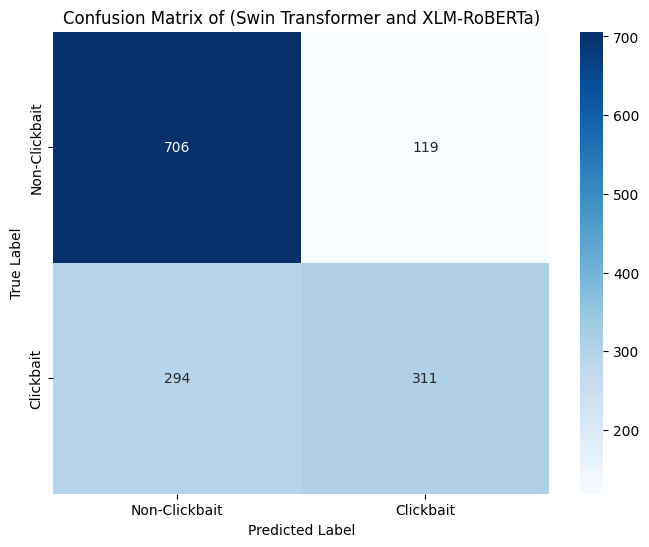

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

print("Loading Best Model for Testing...")
model.load_state_dict(torch.load('best_swin_xlm_fusion.pth', map_location=Config.DEVICE))

test_loss, test_acc, true_labels, pred_labels = eval_model(model, test_loader, criterion, Config.DEVICE)

precision  = precision_score(true_labels, pred_labels, average='binary')
recall     = recall_score(true_labels, pred_labels, average='binary')
f1         = f1_score(true_labels, pred_labels, average='binary')
conf_matrix= confusion_matrix(true_labels, pred_labels)

print("\n" + "="*30)
print("       FINAL TEST RESULTS       ")
print("="*30)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("-" * 30)
print("\nDetailed Classification Report of Swin Transformer and XLM-RoBERTa:")
print(classification_report(true_labels, pred_labels, target_names=['Non-Clickbait', 'Clickbait']))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Clickbait', 'Clickbait'],
            yticklabels=['Non-Clickbait', 'Clickbait'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of (Swin Transformer and XLM-RoBERTa)')
plt.show()

### Cell 11: ROC Curve

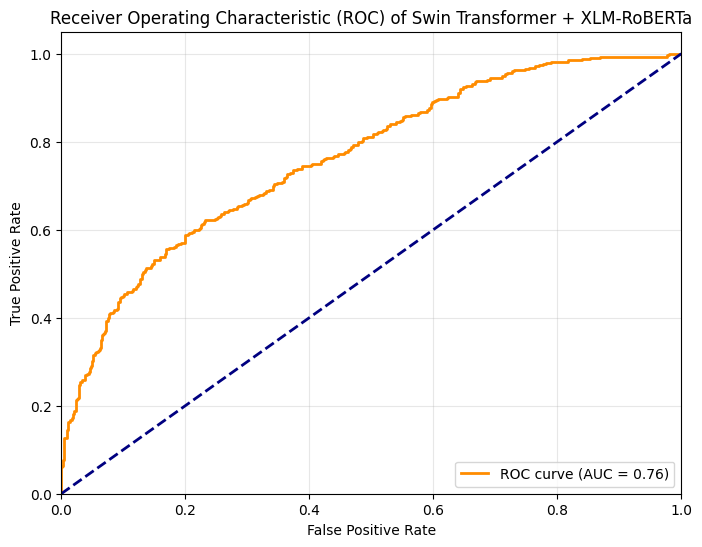

In [14]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, data_loader, device):
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for batch in data_loader:
            pixel_values   = batch['pixel_values'].to(device)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(pixel_values, input_ids, attention_mask)
            probs   = F.softmax(outputs, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) of Swin Transformer + XLM-RoBERTa')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

model.load_state_dict(torch.load('best_swin_xlm_fusion.pth', map_location=Config.DEVICE))
plot_roc_curve(model, test_loader, Config.DEVICE)